# Analise dos resultados obtidos

Foi desenvolvido um sistema de retorno de informação, dado uma tabela deve ser possivel encontrar os documentos canditados para table augmentation dessa tabela.

Sendo assim, os documentos não são simples descrição dos dados tabulares ou documentso técncicos, são contidas informações que podem aumentar o conteudo do tabela 

Para obter esses dados, foi utilizados duas maneiras, documentos reais da wikipedia, formando par tabela e documento.
A outra maneira, foi utilizando tabelas de benchmarks e gerar documentos com LLMs, guiando o modelo a entender os dados para ser um aumentativo das tabela. 
Foi adaptado os benchmark do Spider 1.0, tarefa text-to-sql, e ClaimDB, tarefa de fact-cheking.  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def handle_string_result(data):
    data['Evalution'] = data['Evalution'].str.replace('precision: ','')
    data['Evalution'] = data['Evalution'].str.replace('\nrecall:','')
    data['Evalution'] = data['Evalution'].str.replace('0.0 0.0','0.0')
    data['Evalution'] = data['Evalution'].str.replace('0.2 0.2','0.2')
    data['Evalution'] = data['Evalution'].str.replace('0.4 0.4','0.4')
    data['Evalution'] = data['Evalution'].str.replace('0.6 0.6','0.6')
    data['Evalution'] = data['Evalution'].str.replace('0.8 0.8','0.8')
    data['Evalution'] = data['Evalution'].str.replace('1.0 1.0','1.0')

## Resultado Spider

In [4]:
df_spider_results = pd.read_csv('../data/spider/results.csv')

In [5]:
df_spider_results.head()

,Table,Representation,k,Expected results,Retrieval,Evalution,COS Similary,Num documents,Mean precision and recall
0,artists,serialized_flat,5,"Index([0, 1, 2, 3, 4], dtype='int64')","[4, 0, 2, 1, 3]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 4, 'score': 0.2089151740074157...",50,NaN
1,playlists,serialized_flat,5,"Index([5, 6, 7, 8, 9], dtype='int64')","[8, 6, 7, 5, 9]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 8, 'score': 0.2654455006122589...",50,NaN
2,chip_model,serialized_flat,5,"Index([10, 11, 12, 13, 14], dtype='int64')","[11, 12, 13, 14, 10]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 11, 'score': 0.316323250532150...",50,NaN
3,Video_Games,serialized_flat,5,"Index([15, 16, 17, 18, 19], dtype='int64')","[17, 18, 16, 15, 19]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 17, 'score': 0.366255402565002...",50,NaN
4,employee,serialized_flat,5,"Index([20, 21, 22, 23, 24], dtype='int64')","[22, 23, 20, 24, 21]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 22, 'score': 0.261905342340469...",50,NaN


In [6]:
handle_string_result(df_spider_results)

In [7]:
df_spider_results['Evalution'].unique()

array(['1.0', '0.2', '0.8', '0.6', '0.0', '0.4'], dtype=object)

In [8]:
df_spider_results['Evalution'] = df_spider_results['Evalution'].astype(float)

In [9]:
df_spider_results['Num documents'].max()

200

In [10]:
df_group_rep_spider = df_spider_results.groupby('Representation').agg(mean_hit=('Evalution', 'mean'), median_hit=('Evalution', 'median'))

In [11]:
df_group_rep_spider.sort_values(ascending=False, by='mean_hit', inplace=True)

In [12]:
df_group_rep_spider

,mean_hit,median_hit
Representation,,
markdown,0.992,1.0
serialized_flat,0.984,1.0
linearized_row_wise,0.984,1.0
template_based,0.976,1.0
html_like,0.964,1.0
schema_description,0.912,1.0
contextualized,0.904,1.0
linearized_column_wise,0.872,1.0
column_header_value_triples,0.808,1.0


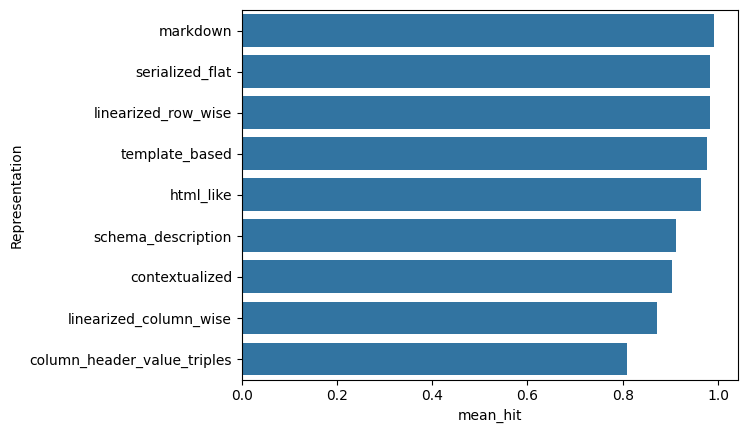

In [13]:
sns.barplot(
    y=df_group_rep_spider.index,
    x=df_group_rep_spider['mean_hit']
)
plt.show()

In [18]:
df_group_rep_doc_spider = df_spider_results.groupby(by=['Representation', 'Num documents']).agg(mean_hit=('Evalution', 'mean'))

In [19]:
df_group_rep_doc_spider

mean_hit
Representation              Num documents          
column_header_value_triples 50                 0.88
                            100                0.79
                            200                0.79
contextualized              50                 0.94
                            100                0.90
                            200                0.89
html_like                   50                 0.98
                            100                0.96
                            200                0.96
linearized_column_wise      50                 0.92
                            100                0.86
                            200                0.86
linearized_row_wise         50                 1.00
                            100                0.98
                            200                0.98
markdown                    50                 1.00
                            100                0.99
                            200                0.99
schema_description          50                 0.94
                            100                0.91
                            200                0.90
serialized_flat             50                 1.00
                            100                0.98
                            200                0.98
template_based              50                 1.00
                            100                0.97
                            200                0.97

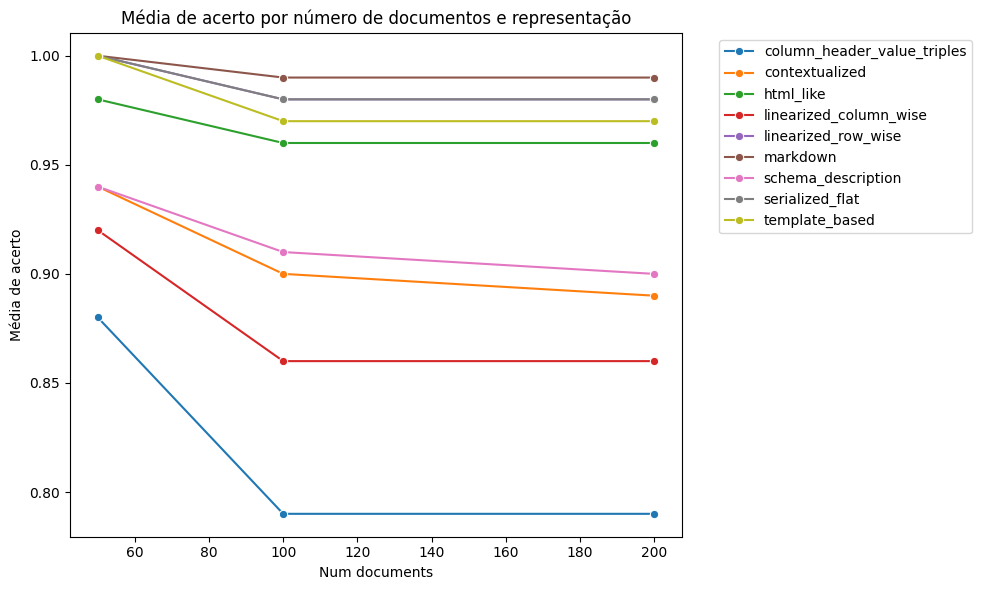

In [20]:
df_plot = df_group_rep_doc_spider.reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot,
    x='Num documents',
    y='mean_hit',
    hue='Representation',   # uma linha por representação
    marker='o'              # marcador em cada época
)

plt.title('Média de acerto por número de documentos e representação')
plt.xlabel('Num documents')
plt.ylabel('Média de acerto')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # legenda fora do gráfico
plt.tight_layout()
plt.show()

## Resultado ClaimDB

In [13]:
df_claim_results = pd.read_csv('../data/claimdb/results_claim.csv')

In [14]:
df_claim_results.head()

,Table,Representation,k,Expected results,Retrieval,Evalution,COS Similary,Num documents
0,drivers,serialized_flat,5,"Index([0, 1, 2, 3, 22], dtype='int64')","[2, 3, 7, 22, 1]",precision: 0.8\nrecall: 0.8,"[[{'corpus_id': 2, 'score': 0.1921548843383789...",50
1,circuits,serialized_flat,5,"Index([4, 5, 6, 7, 8], dtype='int64')","[4, 5, 6, 7, 9]",precision: 0.8\nrecall: 0.8,"[[{'corpus_id': 4, 'score': 0.1488613933324813...",50
2,constructors,serialized_flat,5,"Index([9, 10, 11, 12, 13], dtype='int64')","[9, 11, 12, 13, 10]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 9, 'score': 0.3640146553516388...",50
3,user_reviews,serialized_flat,5,"Index([14, 15, 16, 17, 18], dtype='int64')","[14, 18, 16, 17, 15]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 14, 'score': 0.197763487696647...",50
4,customers,serialized_flat,5,"Index([19, 20, 21, 23, 24], dtype='int64')","[26, 19, 49, 43, 42]",precision: 0.2\nrecall: 0.2,"[[{'corpus_id': 26, 'score': 0.078481718897819...",50


In [15]:
handle_string_result(df_claim_results)

In [16]:
df_claim_results['Evalution'].unique()

array(['0.8', '1.0', '0.2', '0.0', '0.6', '0.4'], dtype=object)

In [17]:
df_claim_results['Evalution'] = df_claim_results['Evalution'].astype(float)

In [18]:
df_claim_results['Num documents'].max()

50

In [19]:
df_group_rep_claim = df_claim_results.groupby('Representation').agg(mean_hit=('Evalution', 'mean'), median_hit=('Evalution', 'median'))

In [20]:
df_group_rep_claim.sort_values(ascending=False, by='mean_hit', inplace=True)

In [21]:
df_group_rep_claim

,mean_hit,median_hit
Representation,,
html_like,0.68,0.8
template_based,0.66,0.8
serialized_flat,0.64,0.8
linearized_row_wise,0.64,0.8
schema_description,0.62,0.8
contextualized,0.62,0.8
markdown,0.60,0.6
linearized_column_wise,0.58,0.6
column_header_value_triples,0.50,0.6


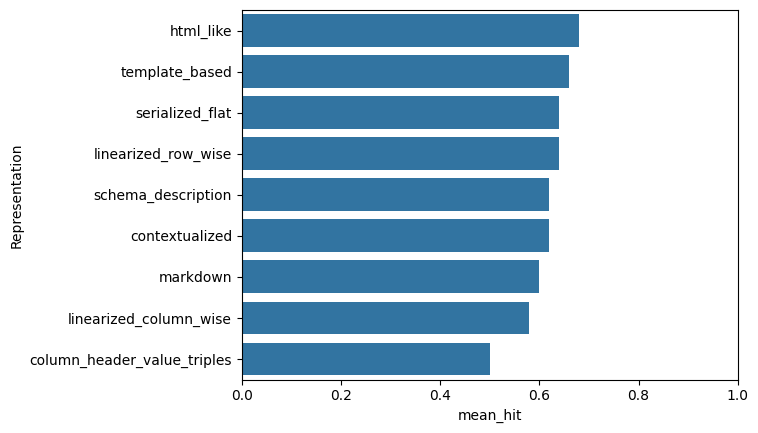

In [38]:
sns.barplot(
    y=df_group_rep_claim.index,
    x=df_group_rep_claim['mean_hit']
)
plt.xlim(0, 1.0)
plt.show()

## Resultado Wikipidia

In [22]:
df_wiki_results = pd.read_csv('../data/wiki/result_wiki.csv')

In [23]:
df_wiki_results.head()

,Table,Representation,k,Expected results,Retrieval,Evalution,COS Similary,Num documents
0,Clubs relegated from Série ACampeonato Brasile...,serialized_flat,1,"Index([0], dtype='int64')",[0],precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 0, 'score': 0.1300806254148483...",52
1,AllotropesCarbon,serialized_flat,1,"Index([4], dtype='int64')",[4],precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 4, 'score': 0.3517859578132629...",52
2,AluminiumAluminium,serialized_flat,1,"Index([22], dtype='int64')",[5],precision: 0.0\nrecall: 0.0,"[[{'corpus_id': 5, 'score': 0.2140078246593475...",52
3,Apollo_11,serialized_flat,1,"Index([], dtype='int64')",[9],precision: 0.0\nrecall: 0.0,"[[{'corpus_id': 9, 'score': 0.3659537136554718}]]",52
4,Automatic speech recognitionDeep learning,serialized_flat,1,"Index([43], dtype='int64')",[43],precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 43, 'score': 0.121263295412063...",52


In [24]:
handle_string_result(df_wiki_results)

In [25]:
df_wiki_results['Evalution'].unique()

array(['1.0', '0.0'], dtype=object)

In [26]:
df_wiki_results['Evalution'] = df_wiki_results['Evalution'].astype(float)

In [27]:
df_group_rep_wiki = df_wiki_results.groupby('Representation').agg(mean_hit=('Evalution', 'mean'), median_hit=('Evalution', 'median'))

In [29]:
df_group_rep_wiki

,mean_hit,median_hit
Representation,,
serialized_flat,0.711538,1.0
linearized_row_wise,0.692308,1.0
template_based,0.673077,1.0
html_like,0.673077,1.0
linearized_column_wise,0.653846,1.0
column_header_value_triples,0.596154,1.0
markdown,0.596154,1.0
schema_description,0.403846,0.0
contextualized,0.384615,0.0


In [28]:
df_group_rep_wiki.sort_values(ascending=False, by='mean_hit', inplace=True)

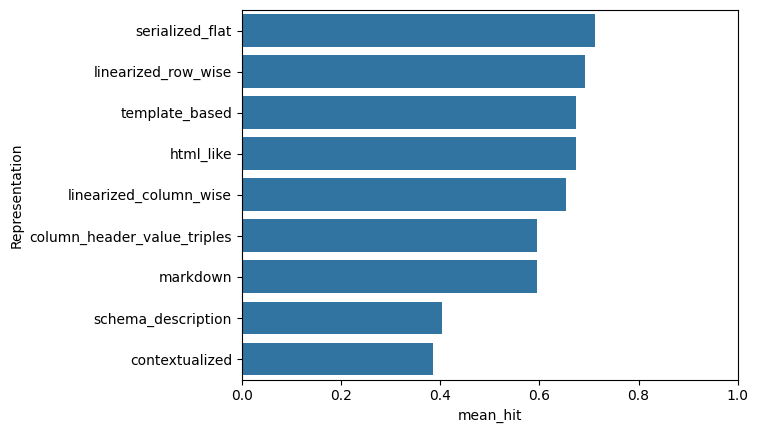

In [39]:
sns.barplot(
    y=df_group_rep_wiki.index,
    x=df_group_rep_wiki['mean_hit']
)
plt.xlim(0, 1.0)
plt.show()

## Resultados Gerais

In [3]:
df_results = pd.read_csv('../data/results_final.csv')

In [4]:
df_results.head()

,Table,Representation,k,Expected results,Retrieval,Evalution,COS Similary,Num documents
0,artists,serialized_flat,5,"Index([0, 1, 2, 3, 4], dtype='int64')","[4, 0, 2, 1, 3]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 4, 'score': 0.2089151740074157...",454
1,playlists,serialized_flat,5,"Index([5, 6, 7, 8, 9], dtype='int64')","[8, 6, 7, 5, 9]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 8, 'score': 0.2654455006122589...",454
2,chip_model,serialized_flat,5,"Index([10, 11, 12, 13, 14], dtype='int64')","[11, 12, 13, 14, 10]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 11, 'score': 0.316323250532150...",454
3,Video_Games,serialized_flat,5,"Index([15, 16, 17, 18, 19], dtype='int64')","[17, 18, 16, 15, 19]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 17, 'score': 0.366255402565002...",454
4,employee,serialized_flat,5,"Index([20, 21, 22, 23, 24], dtype='int64')","[22, 23, 20, 24, 21]",precision: 1.0\nrecall: 1.0,"[[{'corpus_id': 22, 'score': 0.261905342340469...",454


In [5]:
df_results['Evalution'] = df_results['Evalution'].str.replace('precision: ','')
df_results['Evalution'] = df_results['Evalution'].str.replace('\nrecall:','')
df_results['Evalution'] = df_results['Evalution'].str.replace('precision@1: ','')
df_results['Evalution'] = df_results['Evalution'].str.replace('precision@5: ','')
df_results['Evalution'] = df_results['Evalution'].str.replace('1.0 1.0','1.0')
df_results['Evalution'] = df_results['Evalution'].str.replace('0.4 0.4','0.4')
df_results['Evalution'] = df_results['Evalution'].str.replace('0.6 0.6','0.6')
df_results['Evalution'] = df_results['Evalution'].str.replace('0.0 0.0','0.0')
df_results['Evalution'] = df_results['Evalution'].str.replace('0.8 0.8','0.8')

In [6]:
df_results['Evalution'].unique()

array(['1.0', '0.6', '0.4', '0.8', '0.0', '0.2'], dtype=object)

In [7]:
df_results['Evalution'] = df_results['Evalution'].astype(float)

In [8]:
df_group_rep = df_results.groupby('Representation').agg(mean_hit=('Evalution', 'mean'), median_hit=('Evalution', 'median'))

In [9]:
df_group_rep.sort_values(ascending=False, by='mean_hit', inplace=True)

In [10]:
df_group_rep# NOVO (1000 DOCS)

,mean_hit,median_hit
Representation,,
serialized_flat,0.739175,1.0
linearized_row_wise,0.727835,1.0
html_like,0.722680,1.0
template_based,0.719588,1.0
markdown,0.690722,1.0
linearized_column_wise,0.684536,1.0
column_header_value_triples,0.628866,1.0
contextualized,0.568041,0.8
schema_description,0.552577,0.8


In [37]:
df_group_rep# Antigo (400 DOCS) 

,mean_hit,median_hit
Representation,,
serialized_flat,0.756522,1.0
linearized_row_wise,0.739130,1.0
html_like,0.730435,1.0
template_based,0.726087,1.0
markdown,0.700000,1.0
linearized_column_wise,0.682609,1.0
column_header_value_triples,0.623913,1.0
contextualized,0.556522,0.8
schema_description,0.541304,0.8


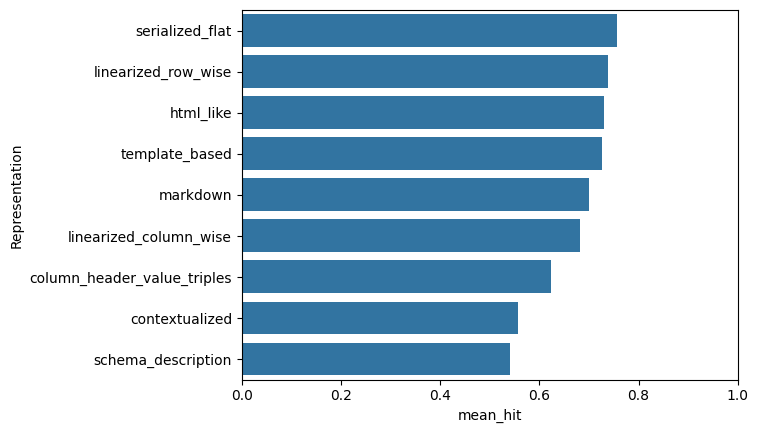

In [40]:
sns.barplot(
    y=df_group_rep.index,
    x=df_group_rep['mean_hit']
)
plt.xlim(0, 1.0)
plt.show()

## TODO:
* Chegar a 1000 docs com apenas raspagem da URL aleatorias que não batam com as que já tenho

* Disponibilizar tabelas

* Rodar atuDDG apenas 5 tabelas

In [11]:
df_final = df_results.groupby(by=['Representation', 'Num documents']).agg(mean_hit=('Evalution', 'mean'), median_hit=('Evalution', 'median'))

In [12]:
df_final

mean_hit  median_hit
Representation              Num documents                      
column_header_value_triples 454            0.623913         1.0
                            1000           0.633333         1.0
contextualized              454            0.556522         0.8
                            1000           0.578431         0.8
html_like                   454            0.730435         1.0
                            1000           0.715686         1.0
linearized_column_wise      454            0.682609         1.0
                            1000           0.686275         1.0
linearized_row_wise         454            0.739130         1.0
                            1000           0.717647         1.0
markdown                    454            0.700000         1.0
                            1000           0.682353         1.0
schema_description          454            0.541304         0.8
                            1000           0.562745         0.8
serialized_flat             454            0.756522         1.0
                            1000           0.723529         1.0
template_based              454            0.726087         1.0
                            1000           0.713725         1.0

In [14]:
df_1000 = df_results[df_results['Num documents'] == 1000]
df_1000.head()

,Table,Representation,k,Expected results,Retrieval,Evalution,COS Similary,Num documents
828,artists,serialized_flat,5,"Index([0, 1, 2, 3, 4], dtype='int64')","[4, 0, 2, 1, 3]",1.0,"[[{'corpus_id': 4, 'score': 0.2089151740074157...",1000
829,playlists,serialized_flat,5,"Index([5, 6, 7, 8, 9], dtype='int64')","[8, 6, 7, 5, 584]",0.8,"[[{'corpus_id': 8, 'score': 0.2654455006122589...",1000
830,chip_model,serialized_flat,5,"Index([10, 11, 12, 13, 14], dtype='int64')","[11, 12, 13, 14, 10]",1.0,"[[{'corpus_id': 11, 'score': 0.316323250532150...",1000
831,Video_Games,serialized_flat,5,"Index([15, 16, 17, 18, 19], dtype='int64')","[17, 18, 16, 15, 19]",1.0,"[[{'corpus_id': 17, 'score': 0.366255402565002...",1000
832,employee,serialized_flat,5,"Index([20, 21, 22, 23, 24], dtype='int64')","[22, 23, 20, 24, 21]",1.0,"[[{'corpus_id': 22, 'score': 0.261905342340469...",1000


In [19]:
df_1000_group = df_1000.groupby('Representation').agg(mean_hit=('Evalution', 'mean'))
df_1000_group.sort_values(ascending=False, by='mean_hit', inplace=True)
df_1000_group.head()

,mean_hit
Representation,
serialized_flat,0.723529
linearized_row_wise,0.717647
html_like,0.715686
template_based,0.713725
linearized_column_wise,0.686275


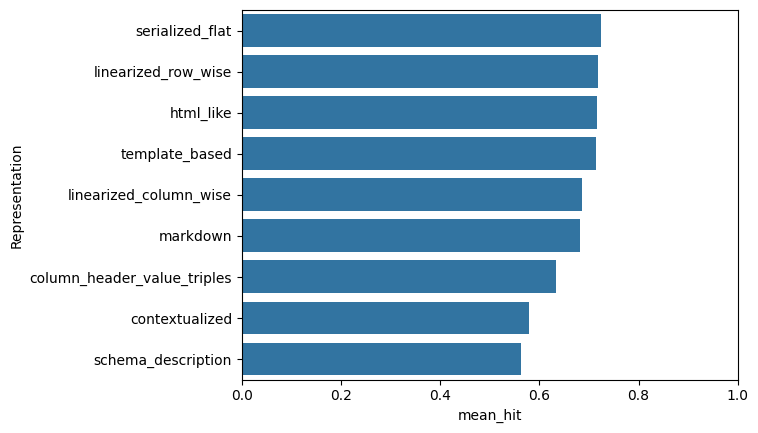

In [18]:
sns.barplot(
    y=df_1000_group.index,
    x=df_1000_group['mean_hit']
)
plt.xlim(0, 1.0)
plt.show()